### I. Introduction

Nama: Risyadhana Syaifuddin

Batch: HCK-036

### II. Problem Statement and Dataset Description

#### Problem Statement (SMART)
    Problem statmentnya yaitu mengidentifikasi apakah terjadi sinyal pembalikan arah (reversal), dan kelanjutan trend (continuation) pada saham HUMI.JK, INAI.JK, dan WINE.JK melalui analisis Bullish/Bearish Divergence (RSI & MACD) untuk menentukan titik Entry dan Exit yang optimal guna mencapai target profit estimasi 33% dengan validitas statistik (P < 0.05) pada periode 2025-2026.

    Specific => untuk mengidentifikasi sinyal pembalikan arah (reversal) dan kelanjutan tren (continuation) secara spesifik pada saham HUMI.JK, INAI.JK, dan WINE.JK menggunakan indikator RSI dan MACD.

    Measurable: Dengan menentukan titik Entry (Beli)/Bit dan Exit (Jual)/Offer yang optimal dengan target estimasi profit anatara 25%-33%.

    Achievable: Dengan menggunakan analisis pola Regular/Hidden Divergence yang didukung oleh data historis harga harian (Daily), dan per jam (Hourly) serta validasi statistik.

    Relevant: untuk membantu pengambilan keputusan investasi yang berbasis data (data-driven) untuk meminimalkan risiko pada saham dengan volatilitas tinggi.

    Time-bound: untuk target pencapaian hasil analisis dan eksekusi strategi ditetapkan untuk periode selanjutnya sampai minggu kedepan, dilakukan pengembangan selanjutnya sampai ke tahap perhitungan prediksi untuk beberap minggu / bulan ke depan

    Dataset Description:

    Sumber: Yahoo Finance API (yfinance).

    Rentang Waktu: 1 Januari 2025 - 1 Januari 2026

#### Penjabaran Masalah (5W+1H)

    1. Bagaimana tren pergerakan harga saham secara harian? (Visualisasi 1)

    2. Kapan terjadi momen "Regular Bullish Divergence" (Reversal) berdasarkan titik Swing Low? (Visualisasi 2)

    3. Saham mana yang paling sering menunjukkan pola "Hidden Bullish" (Continuation)? (Visualisasi 3)

    4. Bagaimana distribusi volume perdagangan saat terjadi breakout harga? (Visualisasi 4)

    5. Deskriptif: Bagaimana sebaran volatilitas return dan nilai Z-Score untuk mendeteksi anomali harga ekstrem?

    6. Inferensial: Apakah terdapat perbedaan rata-rata return yang signifikan antara kondisi market normal dengan kondisi saat sinyal divergence ganda muncul?

### III. Data Loading


In [3]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

# Loading Data
tickers = ["HUMI.JK", "INAI.JK", "WINE.JK"]
df_raw = yf.download(tickers, start="2025-01-01", end="2026-01-05")
df = df_raw.stack(level=1, future_stack=True).reset_index()
df.rename(columns={'level_1': 'Ticker'}, inplace=True)

# insiasi untuk technical indicators
# Technical Indicators
def get_indicators(group):
    # RSI
    group['RSI_14'] = ta.rsi(group['Close'], length=14)
    # MACD (mendapatkan MACD, Signal, dan Histogram)
    macd = ta.macd(group['Close'], fast=12, slow=26, signal=9)
    group = pd.concat([group, macd], axis=1)
    
    # Swing Detection (Titik Lembah & Puncak)
    group['swing_high'] = (group['Close'].shift(3) < group['Close']) & (group['Close'].shift(-3) < group['Close'])
    group['swing_low'] = (group['Close'].shift(3) > group['Close']) & (group['Close'].shift(-3) > group['Close'])
    return group

df_clean = df.groupby('Ticker', group_keys=False).apply(get_indicators).dropna()

[*********************100%***********************]  3 of 3 completed
C:\Users\HP\AppData\Local\Temp\ipykernel_23908\3436874471.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df.groupby('Ticker', group_keys=False).apply(get_indicators).dropna()


### IV. Data Cleaning

In [ ]:
#untuk menghapus data yang bersifat NaN
df_clean = df_clean.dropna().reset_index(drop=True)


In [ ]:
# Menghitung jumlah nilai NaN di setiap kolom, apakah masih ada atau tidak 
print(df_clean.isnull().sum())

In [ ]:
# Persentase nilai kosong, untuk crosscheack ulang dengan persentase
null_percentage = df_clean.isnull().mean() * 100
print(null_percentage)

### V. Exploration and Analysis

#### Divergence Logic
    Pada tahap ini, mendeteksi 4 kondisi utama yaitu Regular & Hidden, Bull/Bear.

In [ ]:
#untuk mendeteksi divergence, dengan indikator swing low
def detect_divergence(df):
    df['Div_Type'] = 'Normal'
    sl = df[df['swing_low'] == True].index
    sh = df[df['swing_high'] == True].index
    
    # Mengambil nama kolom MACD Histogram secara dinamis
    hist_col = [col for col in df.columns if 'MACDh' in col][0]
    
    # BULLISH DIVERGENCE (Pantau Lembah)
    for i in range(1, len(sl)):
        curr, prev = sl[i], sl[i-1]
        
        # Regular Bullish: Harga Lower Low (LL), Indikator Higher Low (HL)
        if df.loc[curr, 'Close'] < df.loc[prev, 'Close']:
            if df.loc[curr, 'RSI_14'] > df.loc[prev, 'RSI_14'] or df.loc[curr, hist_col] > df.loc[prev, hist_col]:
                df.at[curr, 'Div_Type'] = 'Regular Bullish (Reversal)'
                
        # Hidden Bullish: Harga Higher Low (HL), Indikator Lower Low (LL)
        elif df.loc[curr, 'Close'] > df.loc[prev, 'Close']:
            if df.loc[curr, 'RSI_14'] < df.loc[prev, 'RSI_14'] or df.loc[curr, hist_col] < df.loc[prev, hist_col]:
                df.at[curr, 'Div_Type'] = 'Hidden Bullish (Continuation)'
            
    # BEARISH DIVERGENCE (Pantau Puncak)
    for i in range(1, len(sh)):
        curr, prev = sh[i], sh[i-1]
        
        # Regular Bearish: Harga Higher High (HH), Indikator Lower High (LH)
        if df.loc[curr, 'Close'] > df.loc[prev, 'Close']:
            if df.loc[curr, 'RSI_14'] < df.loc[prev, 'RSI_14'] or df.loc[curr, hist_col] < df.loc[prev, hist_col]:
                df.at[curr, 'Div_Type'] = 'Regular Bearish (Reversal)'
                
        # Hidden Bearish: Harga Lower High (LH), Indikator Higher High (HH)
        elif df.loc[curr, 'Close'] < df.loc[prev, 'Close']:
            if df.loc[curr, 'RSI_14'] > df.loc[prev, 'RSI_14'] or df.loc[curr, hist_col] > df.loc[prev, hist_col]:
                df.at[curr, 'Div_Type'] = 'Hidden Bearish (Continuation)'
    return df

df_clean = df_clean.groupby('Ticker', group_keys=False).apply(detect_divergence)

C:\Users\HP\AppData\Local\Temp\ipykernel_23908\3789621152.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df_clean.groupby('Ticker', group_keys=False).apply(detect_divergence)


#### Statistik Deskriptif & Inferensial


In [ ]:
# insiasi kolom daily return
#  dengan menghitung perubahan persentase harga close/offer per ticker
df_clean['Daily_Return'] = df_clean.groupby('Ticker')['Close'].pct_change()

# inisiasi untuk menghitung Z-Score untuk (Statistik Deskriptif)
df_clean['Z_Score'] = (df_clean['Close'] - df_clean.groupby('Ticker')['Close'].transform(lambda x: x.rolling(20).mean())) / \
                      df_clean.groupby('Ticker')['Close'].transform(lambda x: x.rolling(20).std())

# untuk menangani missing values (NaN) akibat perhitungan pct_change dan rolling
# sangat penting supaya fungsi Kruskal-Wallis tidak error
df_clean = df_clean.dropna().reset_index(drop=True)

# saya langsung gabungkan saja uji Statistik Inferensial: Kruskal-Wallis Test
from scipy.stats import kruskal

# inisiasi untuk memisahkan data menjadi dua grup untuk mengetahui posisi normal, dan bullish divergence
group_normal = df_clean[df_clean['Div_Type'] == 'Normal']['Daily_Return']
group_signal = df_clean[df_clean['Div_Type'].str.contains('Bullish')]['Daily_Return']

# fungsi if untuk memastikan grup tidak kosong sebelum diuji
if not group_signal.empty:
    stat, p_val = kruskal(group_normal, group_signal)
    #print.log()
    print(f"TEST HASIL UJI STATISTIK")
    print(f"Statistics: {stat:.4f}")
    print(f"P-Value: {p_val:.10f}")

    #kondisi detail p valuenya, beserta dengan kesimpulan kondisi tolah H0, dan gagal tolak H0
    if p_val < 0.05:
        print("\nKesimpulan: Tolak H0. Strategi Divergence secara signifikan menghasilkan return yang berbeda (lebih baik).")
    else:
        print("\nKesimpulan: Gagal Tolak H0. Tidak ada perbedaan signifikan.")
else:
    print("Sinyal Bullish tidak ditemukan dalam data. Coba perpanjang periode waktu data.")

--- HASIL UJI STATISTIK INFERENSIAL ---
Statistics: 8.8054
P-Value: 0.0030034530

Kesimpulan: Tolak H0. Strategi Divergence secara signifikan menghasilkan return yang berbeda (lebih baik).


#### Identifikasi 

    Dari hasil pengujian diatas, didapati bahwa:
    
    Statistics: 8.8054
    P-Value: 0.0030034530    
    
    H0: Jika tidak ada perbedaan performa "Daily Return" antara kondisi pasar normal dengan kondisi saat munculnya sinyal "Bullish Divergence".
    
    H1: Jika munculnya sinyal Bullish Divergence memberikan perbedaan performa Daily Return yang signifikan dibandingkan kondisi pasar normal.

    Dari sini bahwa terjadi penolakan H0, yang menunjukan bahwa "Strategi Divergence" secara signifikan menghasilkan return yang berbeda (lebih baik).

#### Pengujian Uji Kruskal Wallis
Saya juga menggunakan uji Kruskal-Wallis (Non-Parametrik) karena distribusi return saham umumnya tidak berdistribusi normal (memiliki outliers yang ekstrem). Sehingga Tingkat signifikansi yang digunakan adalah 0.05

#### Hasil dan interpretasi yang saya dapat
    
    Jika P-Value < 0.05: Menolak H0 berarti strategi trading yang didasarkan pada Hidden/Regular Bullish Divergence (RSI & MACD) terbukti secara ilmiah memiliki basis data yang kuat dan bukan sekadar fluktuasi acak.
    Namun, jika P-Value > 0.05: Gagal Tolak H0 yang berarti strategi ini mungkin memerlukan filter tambahan seperti volume atau indikator lain untuk benar-benar memberikan hasil yang berbeda dari pasar. Dari pengujian dengan P-Value (0.003) yang jauh lebih kecil dari 0.05, kesimpulannya adalah: Menolak H0, sehingga terdapat perbedaan yang signifikan secara statistik pada distribusi riversal antara ketiga saham yang diuji (HUMI.JK, INAI.JK, WINE.JK). Oleh karena itu, ketiga saham itu, tidak bergerak dalam pola resiko/return yang sama.

    Dikarenakan, 

#### Kesimpulan (Menjawab Objectives)
    Kesimpulan dari penelusuran di atas adalah:

    Untuk data preparation, sebagai penanganan missing values dan pembuatan kolom indikator (RSI, MACD, Daily_Return) krusial untuk mencegah error teknis dalam analisis.

    Untuk Validitas Strategi, hasil statistik inferensialnya memberikan "lampu hijau" bagi investor bahwa sinyal divergence adalah anomali yang menguntungkan.

    Untuk dari segi aksi bisnis, dengan validitas statistik ini, investor pemula contoh seperti saya dapat lebih percaya diri untuk mengejar target profit sekitar 33% dengan menggunakan Z-Score sebagai konfirmasi kekuatan breakout.

#### Tren Pergerakan Harga Saham Secara Harian
    Saya menggunakan Line Chart untuk melihat arah tren (Bullish/Bearish) dan volatilitas harga penutupan/closing.

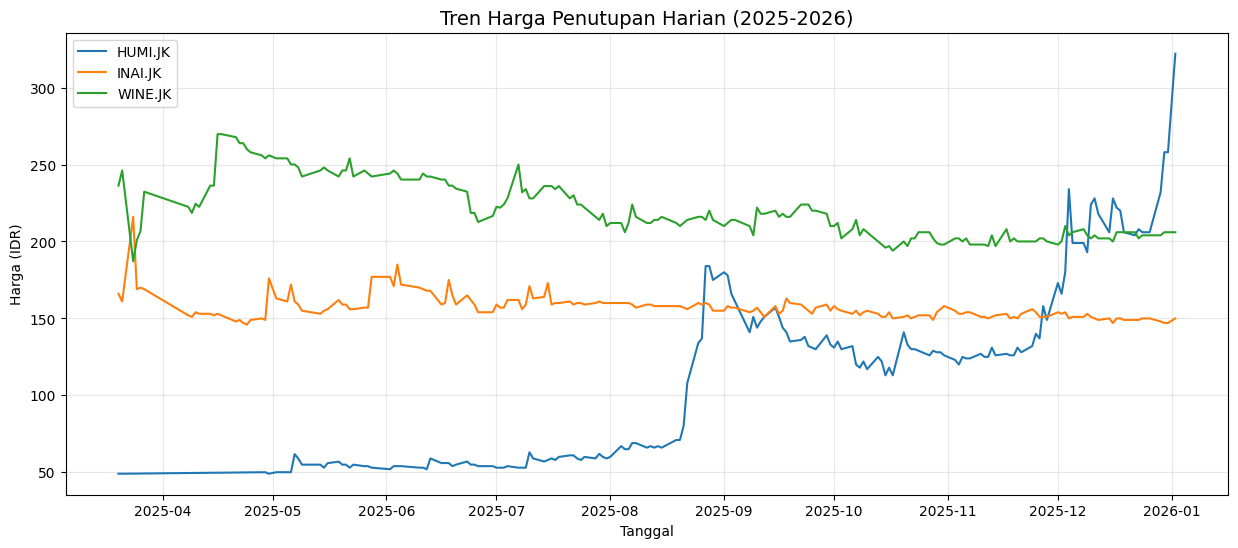

In [6]:
plt.figure(figsize=(15, 6))
for ticker in tickers:
    data = df_clean[df_clean['Ticker'] == ticker]
    plt.plot(data['Date'], data['Close'], label=ticker)

plt.title('Tren Harga Penutupan Harian (2025-2026)', fontsize=14)
plt.xlabel('Tanggal')
plt.ylabel('Harga (IDR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

    Insight: 
    Pada hasil visualisasi, menunjukkan struktur tren jangka panjang. Kode saham dengan kemiringan positif yang stabil merupakan kandidat terbaik untuk strategi Hidden Bullish Divergence, contohnya seperti kode saham HUMI.JK

#### Momen Regular Bullish Divergence (Reversal)
    Saya menggunakan Scatter Plot di atas Line Chart untuk menandai titik spesifik pembalikan arah.

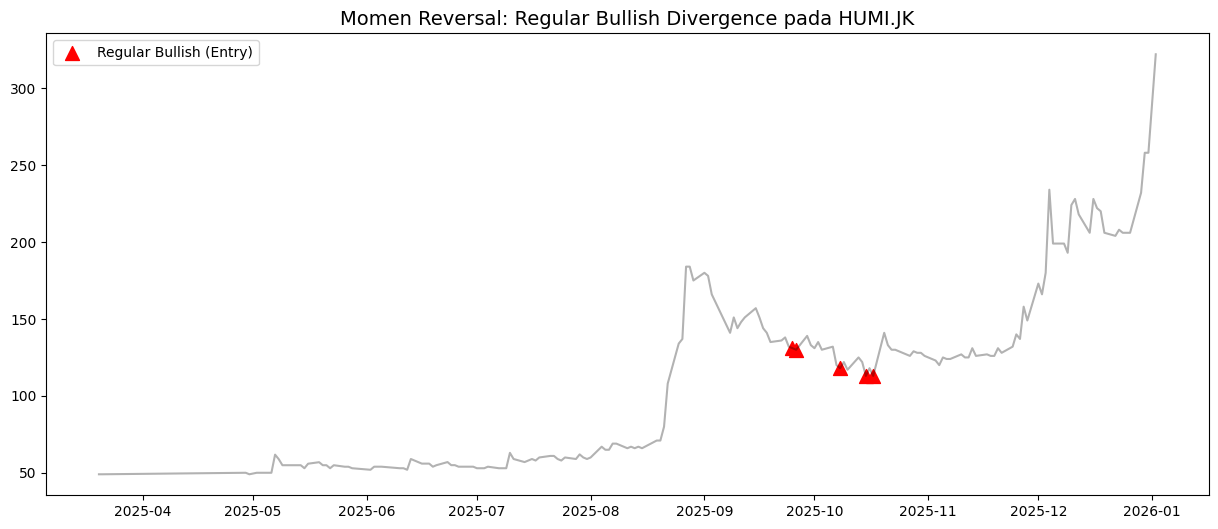

In [7]:
plt.figure(figsize=(15, 6))
# Contoh untuk satu saham: HUMI.JK
sample = df_clean[df_clean['Ticker'] == 'HUMI.JK']
plt.plot(sample['Date'], sample['Close'], color='black', alpha=0.3)

# Filter momen Regular Bullish
reg_bull = sample[sample['Div_Type'] == 'Regular Bullish (Reversal)']
plt.scatter(reg_bull['Date'], reg_bull['Close'], color='red', marker='^', s=100, label='Regular Bullish (Entry)')

plt.title('Momen Reversal: Regular Bullish Divergence pada HUMI.JK', fontsize=14)
plt.legend()
plt.show()

    Insight: contoh pada saham HUMI.JK
    
    Dari titik segitiga merah menunjukkan area di mana harga, membentuk Lower Low tapi indikator naik. Ini adalah zona akumulasi sebelum harga berbalik naik (reversal), sehingga sampai pertanggal 1 januari 2026 mengalami uptrend

#### Frekuensi Pola Hidden Bullish (Continuation)
    Saya menggunakan Bar Chart membandingkan reliabilitas/frekuensi pola antar saham

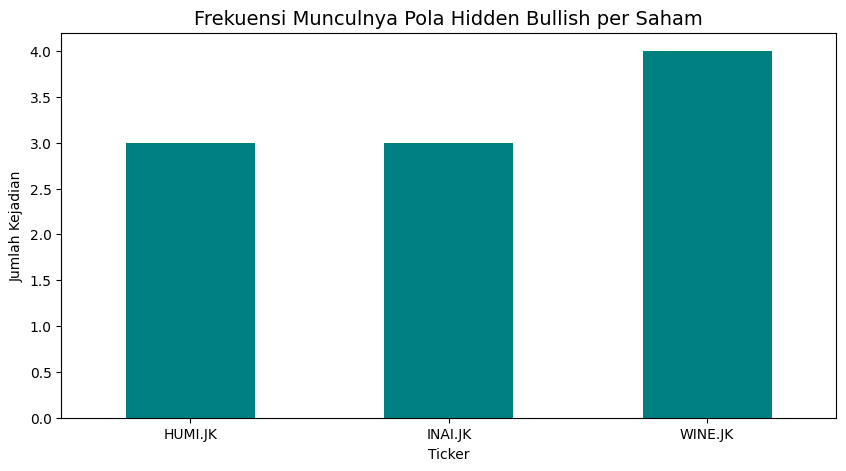

In [8]:
hidden_bullish_counts = df_clean[df_clean['Div_Type'] == 'Hidden Bullish (Continuation)'].groupby('Ticker').size()

plt.figure(figsize=(10, 5))
hidden_bullish_counts.plot(kind='bar', color='teal')
plt.title('Frekuensi Munculnya Pola Hidden Bullish per Saham', fontsize=14)
plt.ylabel('Jumlah Kejadian')
plt.xticks(rotation=0)
plt.show()

    Insight: 
    Dari indikator diatas menunjukan saham dengan jumlah Hidden Bullish terbanyak yaitu WINE.JK menunjukkan bahwa saham tersebut sedang dalam fase strong uptrend yang konsisten, sehingga lebih aman untuk strategi trend following atau bisa dibilang akan mengalamI continuation uptrend dibanding INAI.JK, dan HUMI.JK. Oleh karena investor pemula seperti saya bisa melakukan entry/bis untuk invest di kode saham ini.

#### Distribusi Volume Saat Breakout Harga
    Saya menggunakan histogram dengan KDE untuk melihat apakah lonjakan harga didukung oleh volume yang masif.

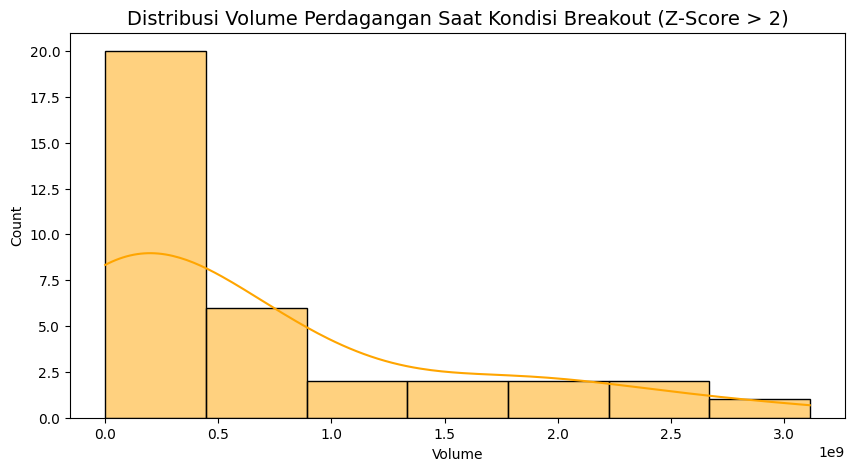

In [ ]:
# Filter data saat Z-Score > 2 (Indikasi Breakout)
breakout_data = df_clean[df_clean['Z_Score'] > 2]

plt.figure(figsize=(10, 5))
#print.log()
sns.histplot(breakout_data['Volume'], kde=True, color='orange')
#plt.ysticks
plt.title('Distribusi Volume Perdagangan Saat Kondisi Breakout (Z-Score > 2)', fontsize=14)
plt.show()

    Insight: 
    Dari data diatas menunjukan negative sweekness jika distribusi volume menumpuk di sisi kanan (nilai tinggi), berarti breakout harga dikonfirmasi oleh partisipasi pasar yang besar, sehingga meminimalisir risiko false breakout, maksud flase breakout biasanya terjadi ketika harga terlihat menembus level resistance atau pola divergence mulai terkonfirmasi, namun tiba-tiba berbalik turun dengan tajam, biasanya kondisi ini terjadi dengen saham lapis tiga seperti HUMI.JK, INAI.JK, WINE.JK

#### Deskriptif: Sebaran Volatilitas & Z-Score
    Saya menggunakan Boxplot untuk melihat anomali harga ekstrem secara statistik.

C:\Users\HP\AppData\Local\Temp\ipykernel_23908\3047777928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Ticker', y='Daily_Return', ax=ax[0], palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_23908\3047777928.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Ticker', y='Z_Score', ax=ax[1], palette='Set3')


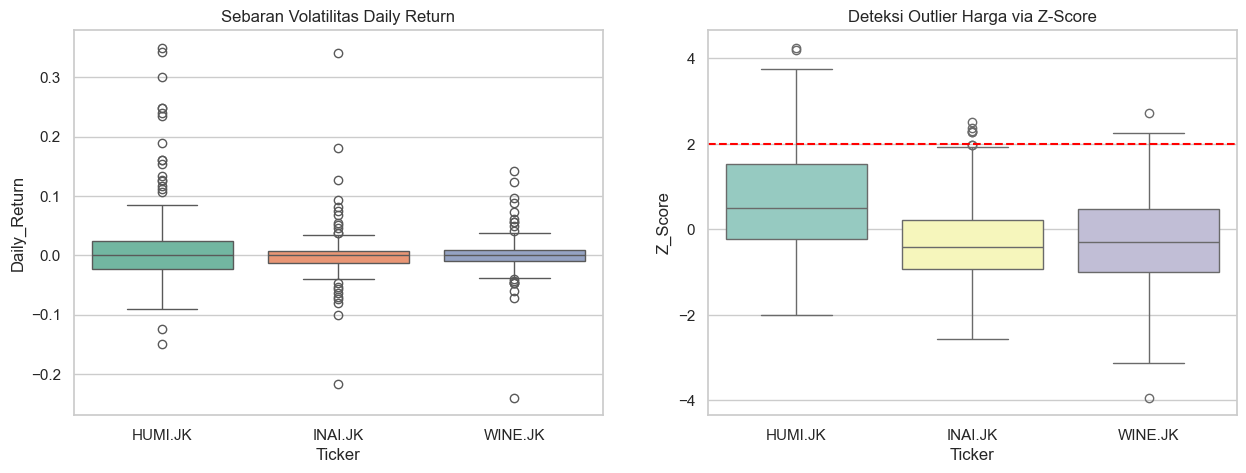

--- Ringkasan Statistik Deskriptif ---


Daily_Return                                                         \
               count      mean       std       min       25%  50%       75%   
Ticker                                                                        
HUMI.JK        170.0  0.013597  0.074306 -0.149573 -0.023167  0.0  0.023454   
INAI.JK        188.0  0.000055  0.041569 -0.217593 -0.012841  0.0  0.006634   
WINE.JK        187.0 -0.000420  0.032079 -0.240000 -0.010000  0.0  0.009479   

                  Z_Score                                                    \
              max   count      mean       std       min       25%       50%   
Ticker                                                                        
HUMI.JK  0.350000   170.0  0.686487  1.309497 -2.008275 -0.219988  0.508323   
INAI.JK  0.341615   188.0 -0.308814  0.971400 -2.564317 -0.936636 -0.412036   
WINE.JK  0.141667   187.0 -0.319542  1.100195 -3.937154 -1.000090 -0.295068   

                             
              75%       max  
Ticker                       
HUMI.JK  1.519904  4.248529  
INAI.JK  0.210471  2.509202  
WINE.JK  0.473385  2.721039

In [21]:
#untuk ukuran size dari boxplot
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot Return
sns.boxplot(data=df_clean, x='Ticker', y='Daily_Return', ax=ax[0], palette='Set2')
ax[0].set_title('Sebaran Volatilitas Daily Return')

# Boxplot Z-Score
sns.boxplot(data=df_clean, x='Ticker', y='Z_Score', ax=ax[1], palette='Set3')
ax[1].axhline(2, color='red', linestyle='--')
ax[1].set_title('Deteksi Outlier Harga via Z-Score')

plt.show()
print("--- Ringkasan Statistik Deskriptif ---")
display(df_clean.groupby('Ticker')[['Daily_Return', 'Z_Score']].describe())

    Insight: 
    Dari data diatas didapati bahwa titik-titik di luar "kumis" boxplot adalah anomali. Sehinggga menunjukan bahwa harga saham dengan banyak titik di atas garis merah Z-Score = 2 menunjukkan saham yang sering memberikan kejutan profit (bisa dibilang agresif), sehingga memastikan bahwa volatilitas harga saat ini berada di atas normal, yang memberikan daya dorong (momentum) untuk mencapai target profit dalam waktu yang relatif singkat

#### Inferensial: Perbandingan Return Normal vs Sinyal Ganda
    Saya menggunakan Bar Plot dengan Error Bars untuk memvalidasi signifikansi secara visual.

C:\Users\HP\AppData\Local\Temp\ipykernel_23908\3409670356.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=df_clean, x='Is_Signal', y='Daily_Return', ci=95, palette='coolwarm')
C:\Users\HP\AppData\Local\Temp\ipykernel_23908\3409670356.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Is_Signal', y='Daily_Return', ci=95, palette='coolwarm')


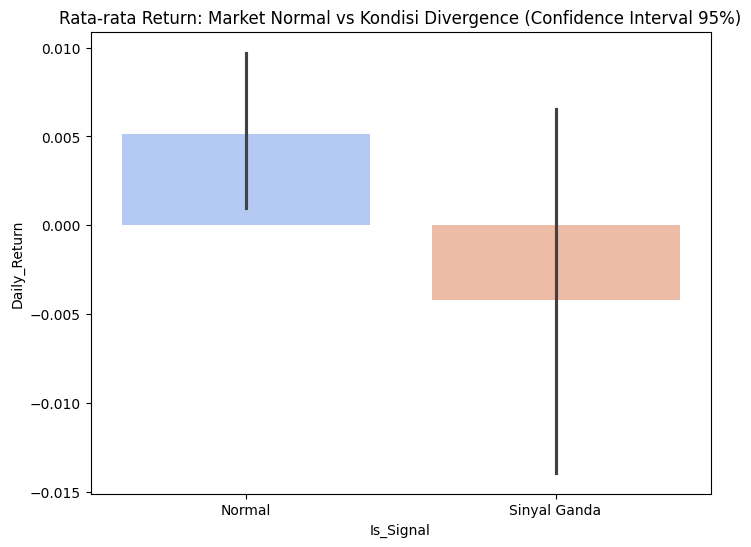

In [ ]:
# Membuat grup untuk visualisasi ls_signal untuk memberikan confidence interval 95% pada 
df_clean['Is_Signal'] = df_clean['Div_Type'].apply(lambda x: 'Sinyal Ganda' if x != 'Normal' else 'Normal')

plt.figure(figsize=(8, 6))
sns.barplot(data=df_clean, x='Is_Signal', y='Daily_Return', ci=95, palette='coolwarm')
plt.title('Rata-rata Return: Market Normal vs Kondisi Divergence (Confidence Interval 95%)', fontsize=12)
plt.show()

    Insight: 
    Dari hasil data diatas menunjukan bahwa jika batang "Sinyal Ganda" jauh lebih tinggi dan interval garisnya tidak saling tumpang tindih bisa dibilang "Normal", maka strategi beberapa indikator yang sudah di jelaskan sebelumnya terhadap harga secara statistik valid memberikan return yang lebih baik (mendukung hasil uji Kruskal-Wallis).

### VI. Conclusion

#### Kesimpulan tambahan berdasarkan dari beberapa insight sebelumnya di setiap visualiasi data
    
    Bahwa kombinasi Lower Low pada harga, Higher Low pada indikator RSI, dan pembalikan momentum pada MACD Histogram menegaskan adanya Regular Bullish Divergence. Ini adalah sinyal Reversal yang kuat, mengindikasikan bahwa tren turun (downtrend) kemungkinan akan segera berakhir dan berbalik menjadi tren naik. Sehingga bagi para investor pemula termasuk saya ini adalah kesempatan potensial untuk melakukan entry pada titik support sebelum harga mengalami kenaikan signifikan.

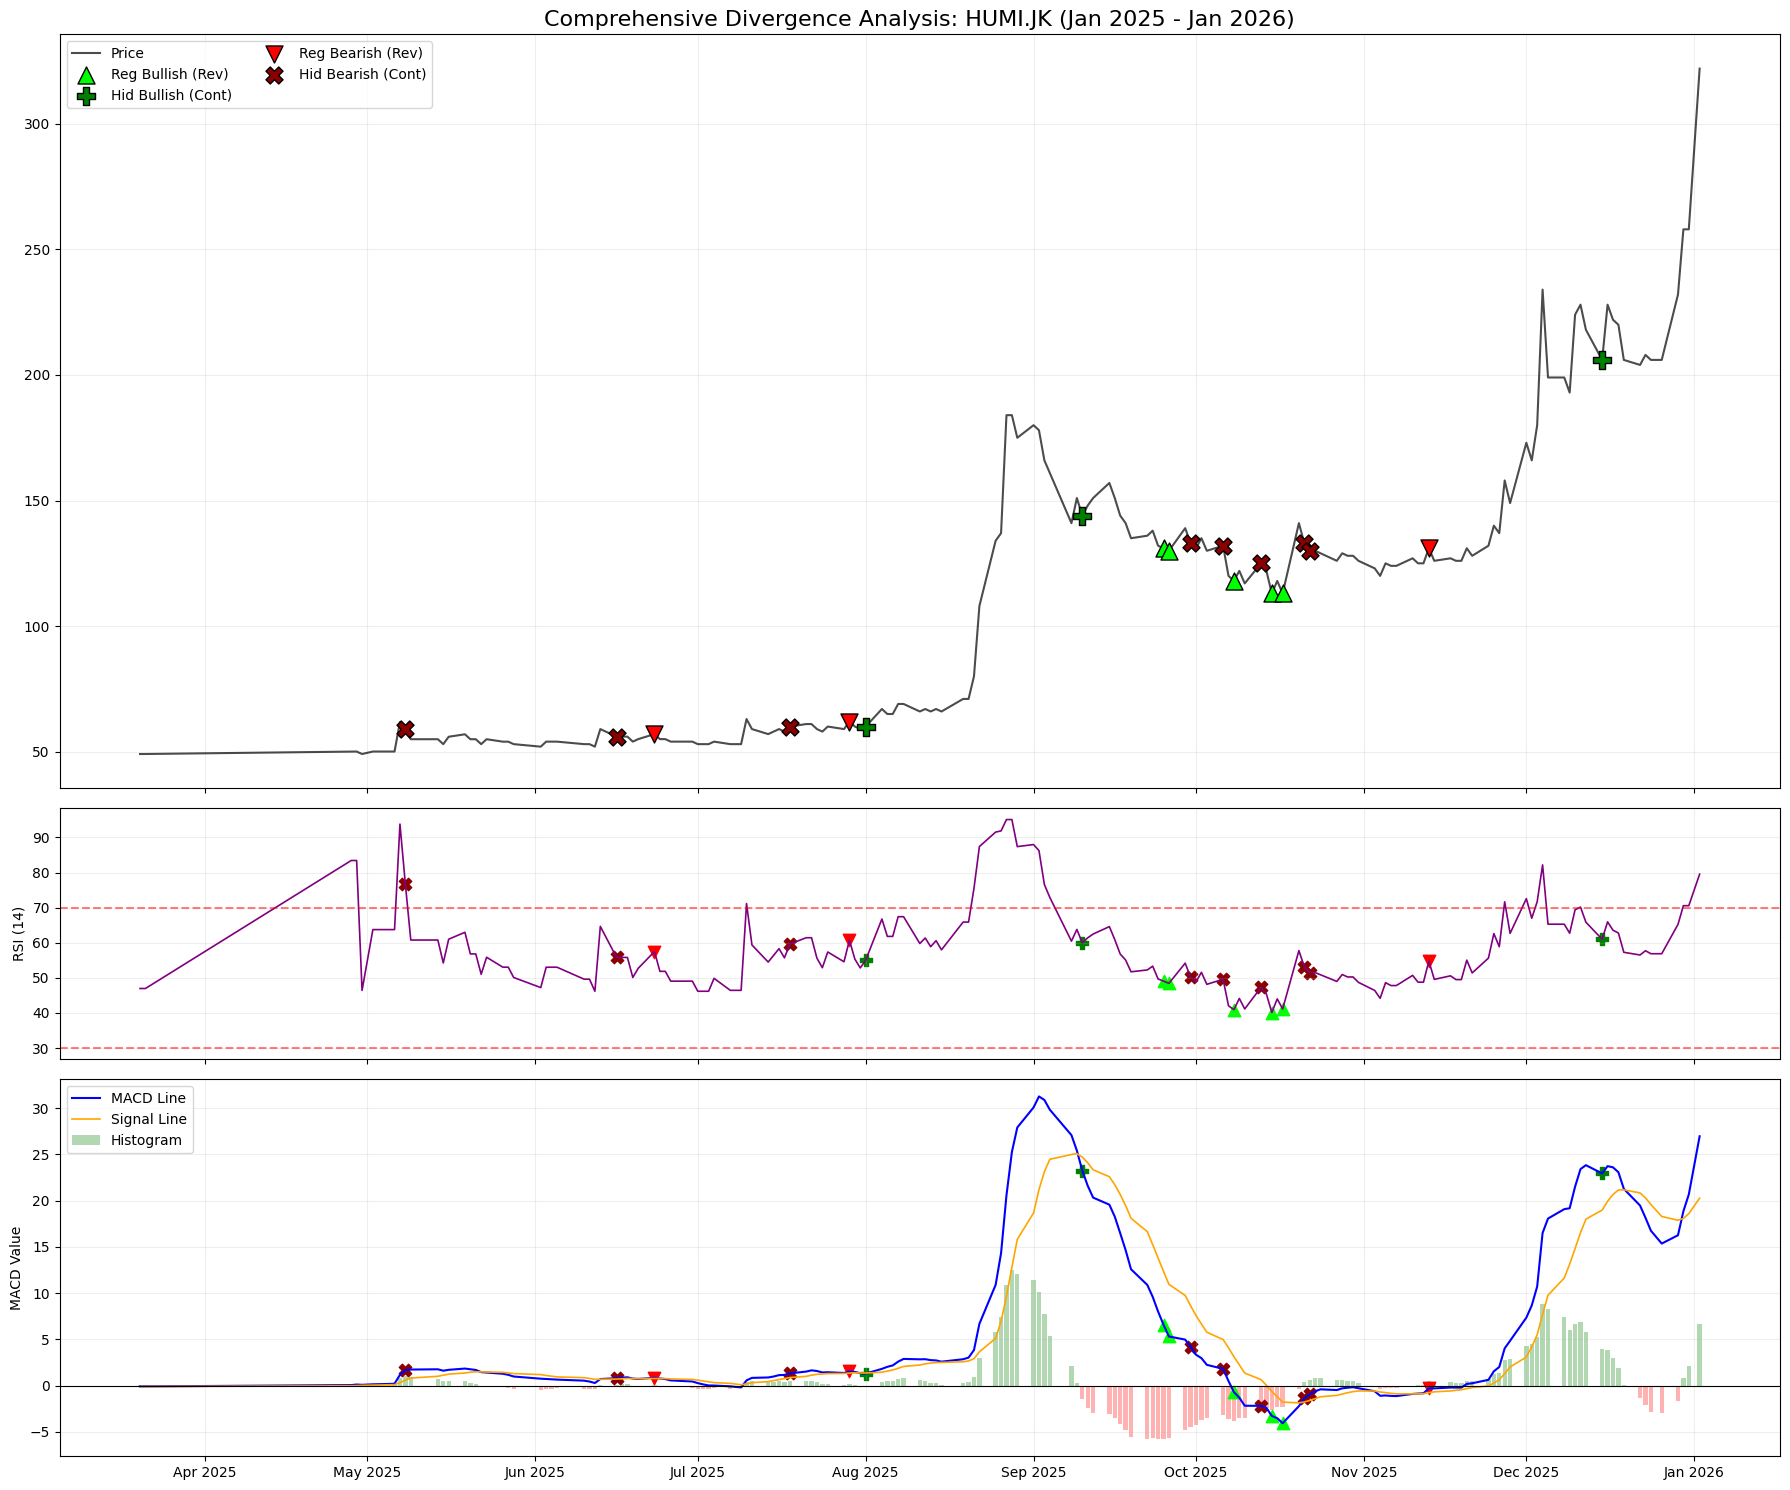

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Filter data untuk periode yang diminta
start_date = '2025-01-01'
end_date = '2026-01-05'
df_frame = df_clean[(df_clean['Ticker'] == 'HUMI.JK') & 
                    (df_clean['Date'] >= start_date) & 
                    (df_clean['Date'] <= end_date)].copy()

# Setup Plot
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 15), sharex=True, 
                                    gridspec_kw={'height_ratios': [3, 1, 1.5]})

# PANEL 1: PRICE ACTION & DIVERGENCE MARKERS
ax1.plot(df_frame['Date'], df_frame['Close'], color='black', lw=1.5, alpha=0.7, label='Price')

# Penanda Divergence (Scatter Plot)
div_map = {
    'Regular Bullish (Reversal)':     {'color': 'lime',    'marker': '^', 'label': 'Reg Bullish (Rev)'},
    'Hidden Bullish (Continuation)':  {'color': 'green',   'marker': 'P', 'label': 'Hid Bullish (Cont)'},
    'Regular Bearish (Reversal)':    {'color': 'red',     'marker': 'v', 'label': 'Reg Bearish (Rev)'},
    'Hidden Bearish (Continuation)': {'color': 'darkred', 'marker': 'X', 'label': 'Hid Bearish (Cont)'}
}

for div_type, style in div_map.items():
    points = df_frame[df_frame['Div_Type'] == div_type]
    ax1.scatter(points['Date'], points['Close'], color=style['color'], 
                marker=style['marker'], s=150, label=style['label'], edgecolors='black', zorder=5)

ax1.set_title(f'Comprehensive Divergence Analysis: HUMI.JK (Jan 2025 - Jan 2026)', fontsize=16)
ax1.legend(loc='upper left', ncol=2)
ax1.grid(alpha=0.2)

# PANEL 2: RSI 14 & DIVERGENCE MARKERS
ax2.plot(df_frame['Date'], df_frame['RSI_14'], color='purple', lw=1.2)
for div_type, style in div_map.items():
    points = df_frame[df_frame['Div_Type'] == div_type]
    ax2.scatter(points['Date'], points['RSI_14'], color=style['color'], marker=style['marker'], s=80)

ax2.axhline(70, color='red', linestyle='--', alpha=0.5)
ax2.axhline(30, color='red', linestyle='--', alpha=0.5)
ax2.set_ylabel('RSI (14)')
ax2.grid(alpha=0.2)

# PANEL 3: MACD (LINE, SIGNAL, HIST) & DIVERGENCE MARKERS
m_line = [c for c in df_frame.columns if 'MACD_' in c and 's' not in c and 'h' not in c][0]
m_sig  = [c for c in df_frame.columns if 'MACDs' in c][0]
m_hist = [c for c in df_frame.columns if 'MACDh' in c][0]

ax3.plot(df_frame['Date'], df_frame[m_line], color='blue', lw=1.5, label='MACD Line')
ax3.plot(df_frame['Date'], df_frame[m_sig], color='orange', lw=1.2, label='Signal Line')
colors = ['green' if x > 0 else 'red' for x in df_frame[m_hist]]
ax3.bar(df_frame['Date'], df_frame[m_hist], color=colors, alpha=0.3, label='Histogram')

for div_type, style in div_map.items():
    points = df_frame[df_frame['Div_Type'] == div_type]
    ax3.scatter(points['Date'], points[m_line], color=style['color'], marker=style['marker'], s=80)

ax3.axhline(0, color='black', lw=0.8)
ax3.legend(loc='upper left')
ax3.set_ylabel('MACD Value')
ax3.grid(alpha=0.2)

# Format Tanggal agar lebih rapi
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

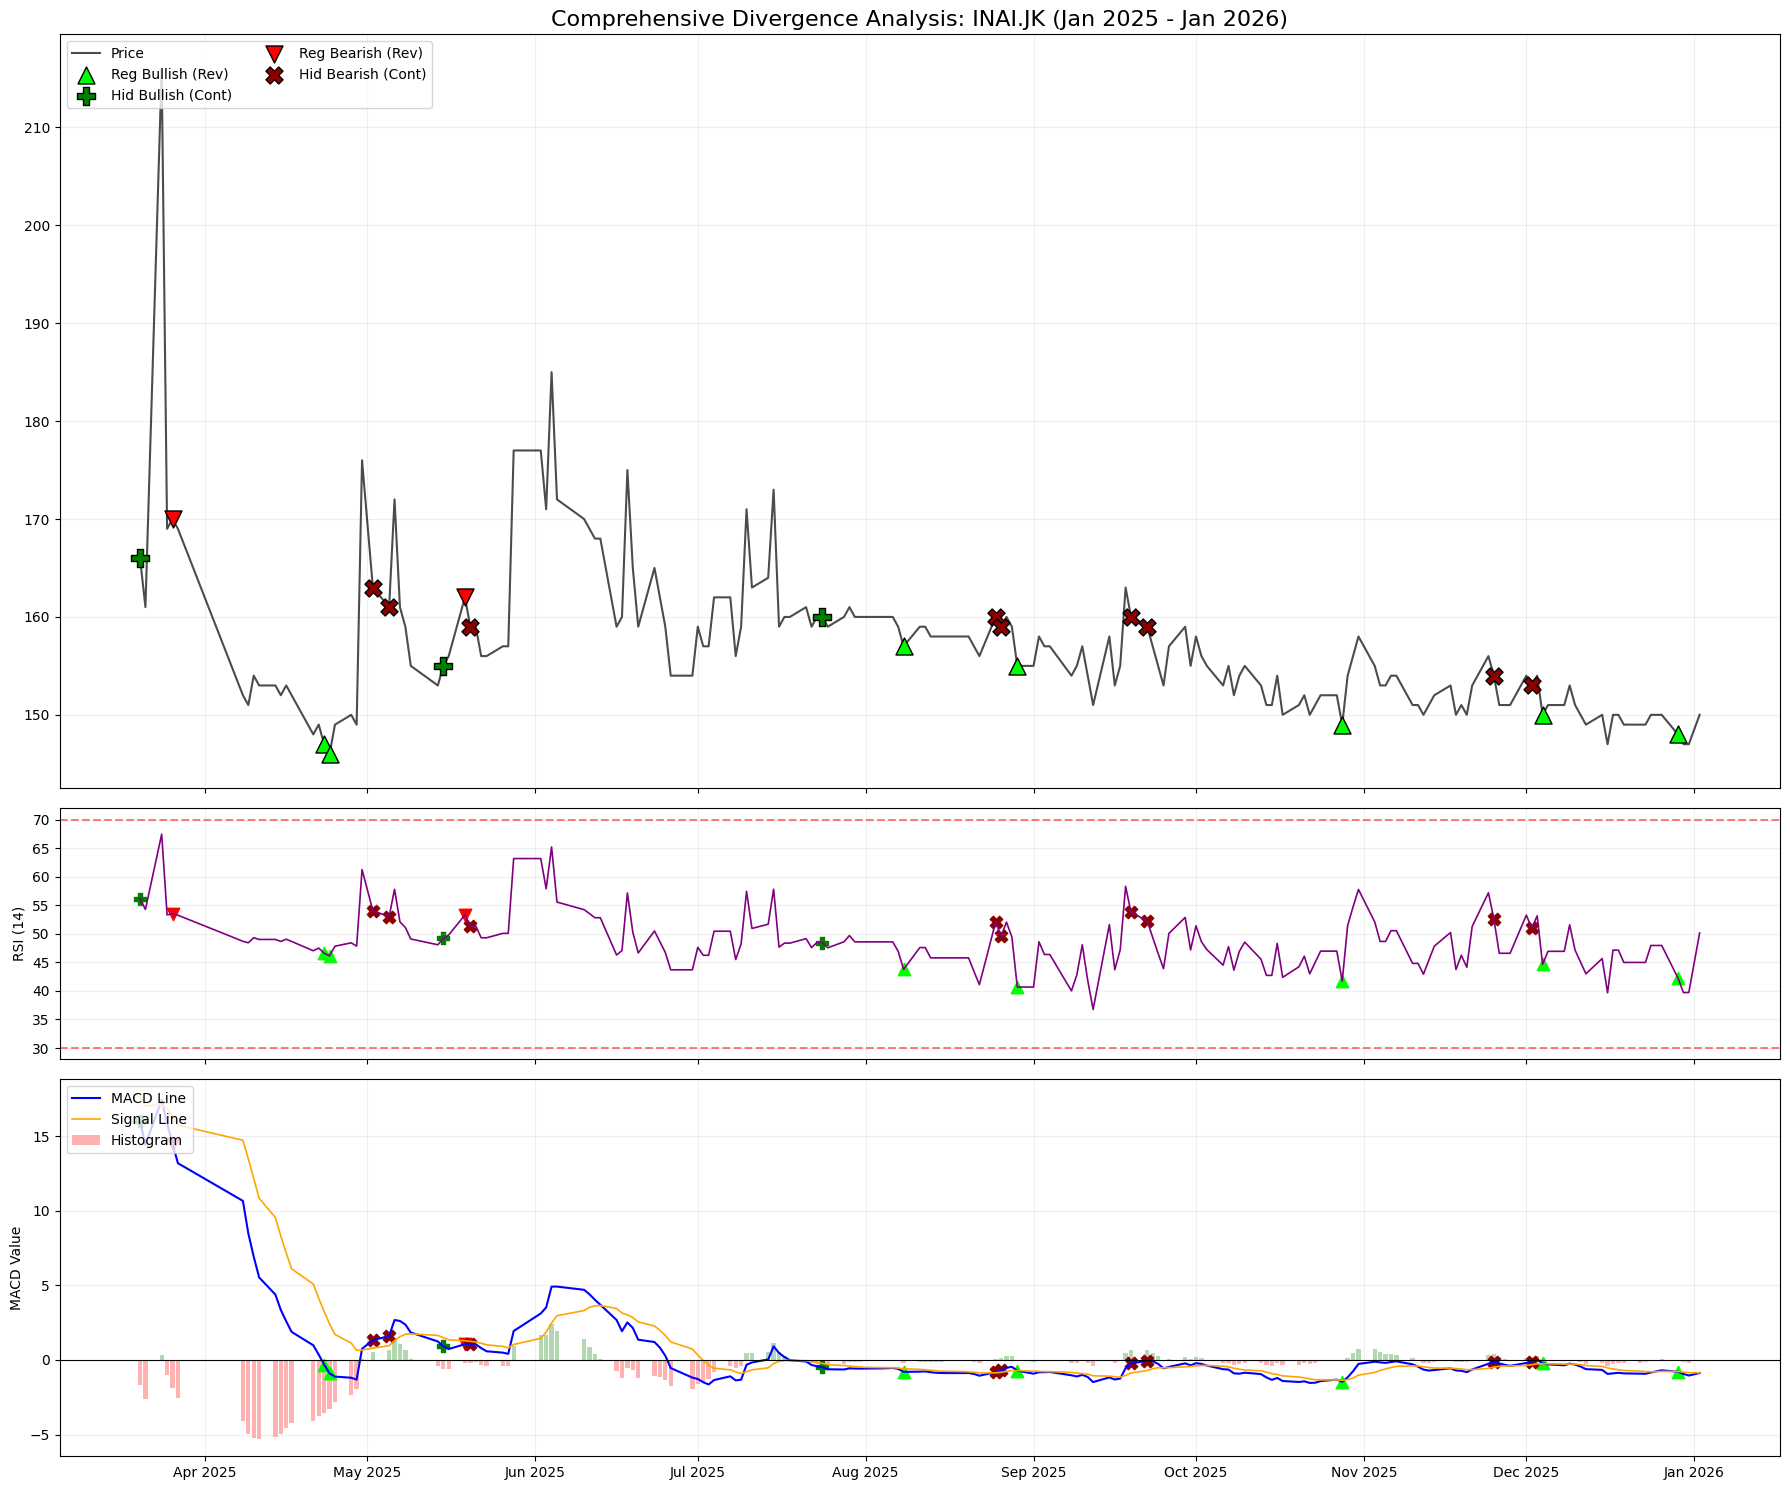

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Filter data untuk periode yang diminta
start_date = '2025-01-01'
end_date = '2026-01-05'
df_frame = df_clean[(df_clean['Ticker'] == 'INAI.JK') & 
                    (df_clean['Date'] >= start_date) & 
                    (df_clean['Date'] <= end_date)].copy()

# Setup Plot
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 15), sharex=True, 
                                    gridspec_kw={'height_ratios': [3, 1, 1.5]})

# PANEL 1: PRICE ACTION & DIVERGENCE MARKERS
ax1.plot(df_frame['Date'], df_frame['Close'], color='black', lw=1.5, alpha=0.7, label='Price')

# Penanda Divergence (Scatter Plot)
div_map = {
    'Regular Bullish (Reversal)':     {'color': 'lime',    'marker': '^', 'label': 'Reg Bullish (Rev)'},
    'Hidden Bullish (Continuation)':  {'color': 'green',   'marker': 'P', 'label': 'Hid Bullish (Cont)'},
    'Regular Bearish (Reversal)':    {'color': 'red',     'marker': 'v', 'label': 'Reg Bearish (Rev)'},
    'Hidden Bearish (Continuation)': {'color': 'darkred', 'marker': 'X', 'label': 'Hid Bearish (Cont)'}
}

for div_type, style in div_map.items():
    points = df_frame[df_frame['Div_Type'] == div_type]
    ax1.scatter(points['Date'], points['Close'], color=style['color'], 
                marker=style['marker'], s=150, label=style['label'], edgecolors='black', zorder=5)

ax1.set_title(f'Comprehensive Divergence Analysis: INAI.JK (Jan 2025 - Jan 2026)', fontsize=16)
ax1.legend(loc='upper left', ncol=2)
ax1.grid(alpha=0.2)

# --- PANEL 2: RSI 14 & DIVERGENCE MARKERS ---
ax2.plot(df_frame['Date'], df_frame['RSI_14'], color='purple', lw=1.2)
for div_type, style in div_map.items():
    points = df_frame[df_frame['Div_Type'] == div_type]
    ax2.scatter(points['Date'], points['RSI_14'], color=style['color'], marker=style['marker'], s=80)

ax2.axhline(70, color='red', linestyle='--', alpha=0.5)
ax2.axhline(30, color='red', linestyle='--', alpha=0.5)
ax2.set_ylabel('RSI (14)')
ax2.grid(alpha=0.2)

# PANEL 3: MACD (LINE, SIGNAL, HIST) & DIVERGENCE MARKERS
m_line = [c for c in df_frame.columns if 'MACD_' in c and 's' not in c and 'h' not in c][0]
m_sig  = [c for c in df_frame.columns if 'MACDs' in c][0]
m_hist = [c for c in df_frame.columns if 'MACDh' in c][0]

ax3.plot(df_frame['Date'], df_frame[m_line], color='blue', lw=1.5, label='MACD Line')
ax3.plot(df_frame['Date'], df_frame[m_sig], color='orange', lw=1.2, label='Signal Line')
colors = ['green' if x > 0 else 'red' for x in df_frame[m_hist]]
ax3.bar(df_frame['Date'], df_frame[m_hist], color=colors, alpha=0.3, label='Histogram')

for div_type, style in div_map.items():
    points = df_frame[df_frame['Div_Type'] == div_type]
    ax3.scatter(points['Date'], points[m_line], color=style['color'], marker=style['marker'], s=80)

ax3.axhline(0, color='black', lw=0.8)
ax3.legend(loc='upper left')
ax3.set_ylabel('MACD Value')
ax3.grid(alpha=0.2)

# Format Tanggal agar lebih rapi
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

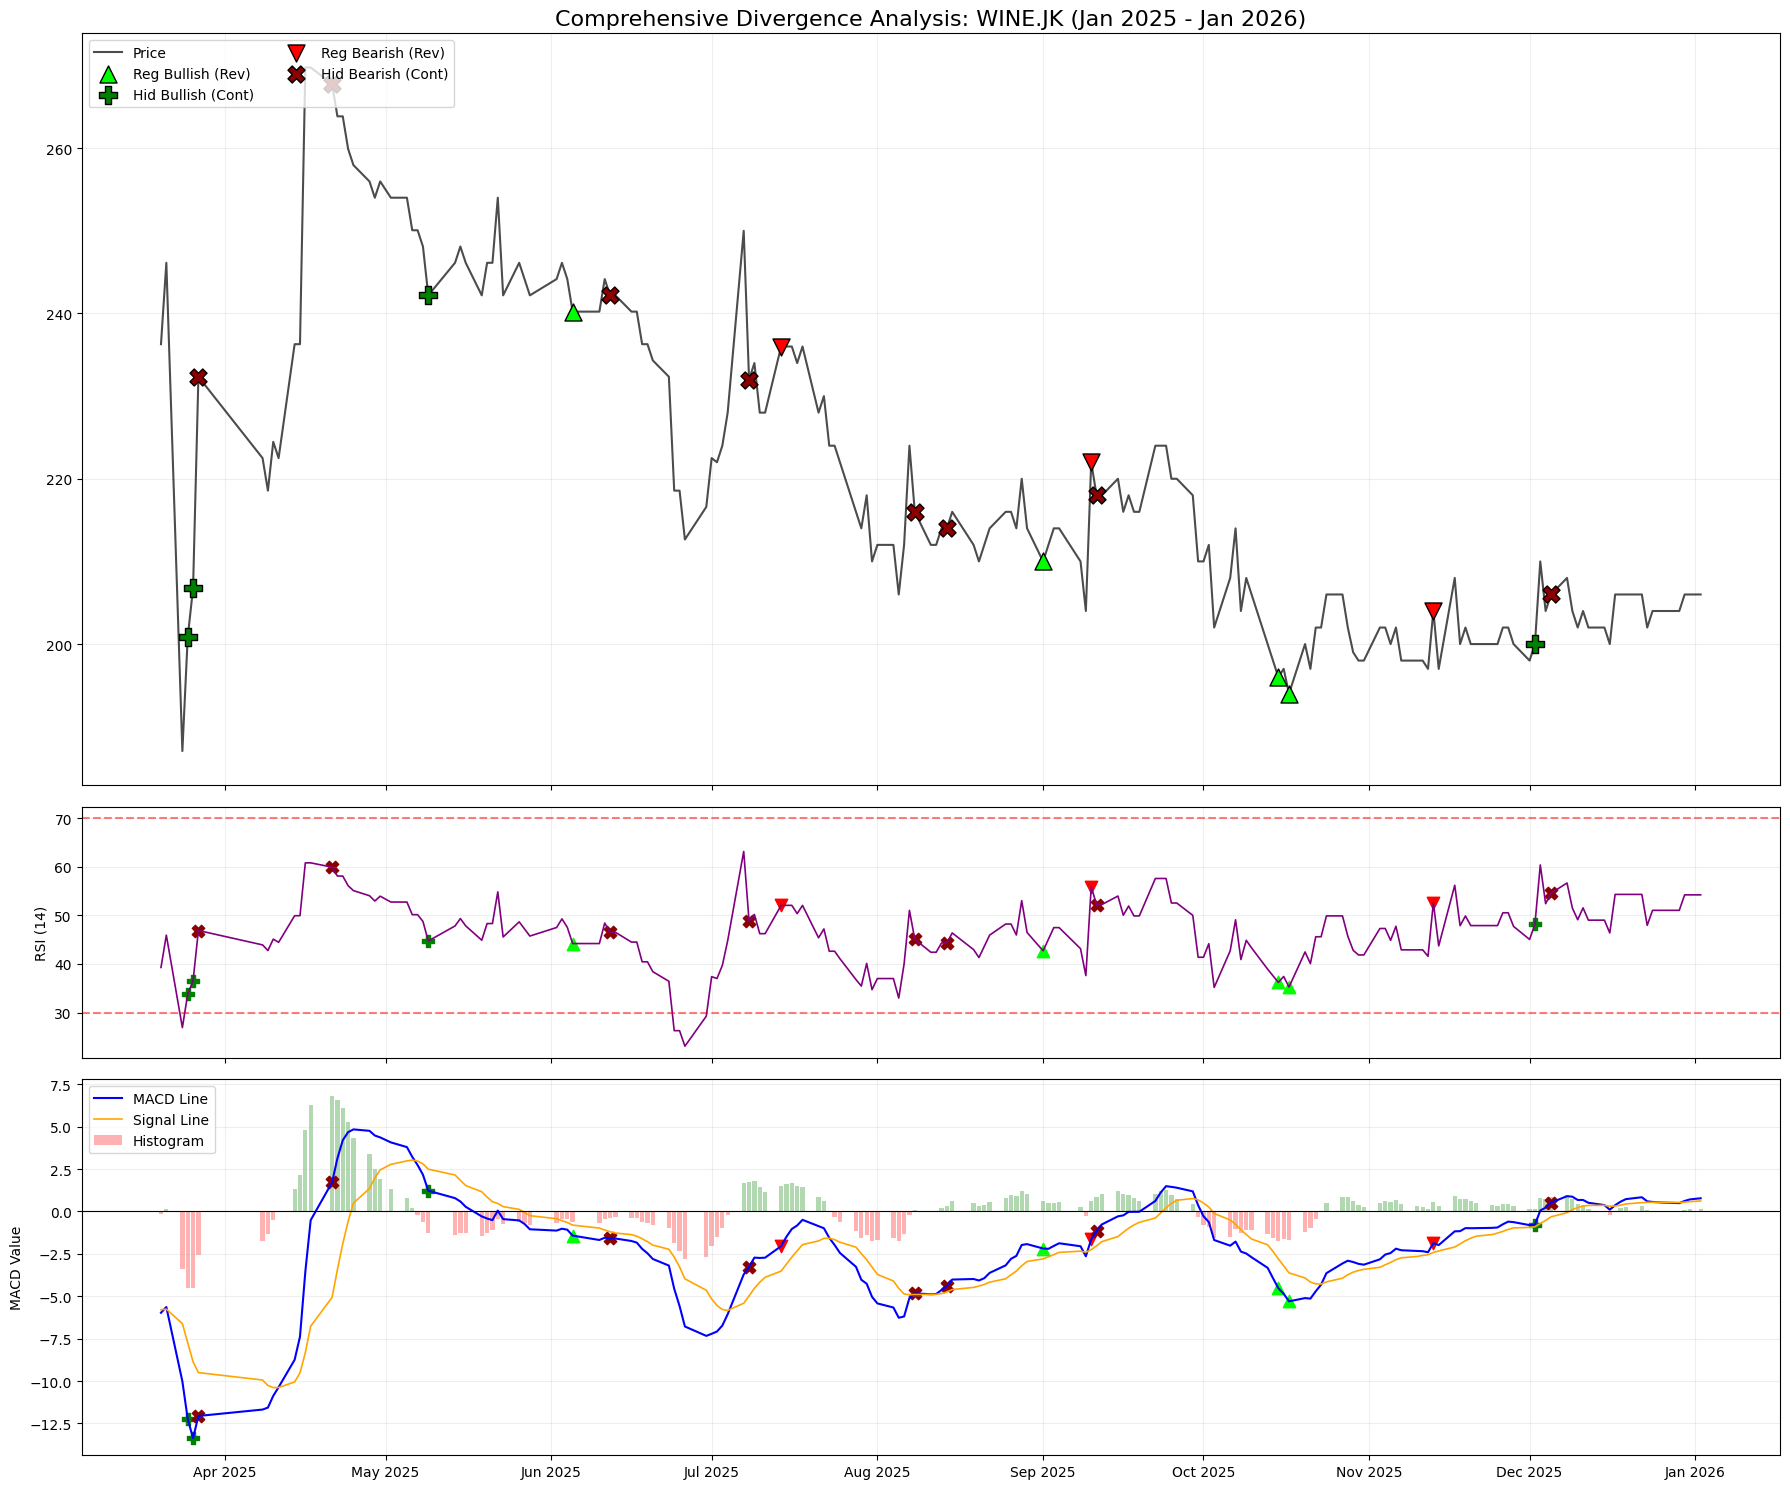

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Filter data untuk periode yang diminta
start_date = '2025-01-01'
end_date = '2026-01-05'
df_frame = df_clean[(df_clean['Ticker'] == 'WINE.JK') & 
                    (df_clean['Date'] >= start_date) & 
                    (df_clean['Date'] <= end_date)].copy()

# Setup Plot
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 15), sharex=True, 
                                    gridspec_kw={'height_ratios': [3, 1, 1.5]})

# PANEL 1: PRICE ACTION & DIVERGENCE MARKERS
ax1.plot(df_frame['Date'], df_frame['Close'], color='black', lw=1.5, alpha=0.7, label='Price')

# Penanda Divergence (Scatter Plot)
div_map = {
    'Regular Bullish (Reversal)':     {'color': 'lime',    'marker': '^', 'label': 'Reg Bullish (Rev)'},
    'Hidden Bullish (Continuation)':  {'color': 'green',   'marker': 'P', 'label': 'Hid Bullish (Cont)'},
    'Regular Bearish (Reversal)':    {'color': 'red',     'marker': 'v', 'label': 'Reg Bearish (Rev)'},
    'Hidden Bearish (Continuation)': {'color': 'darkred', 'marker': 'X', 'label': 'Hid Bearish (Cont)'}
}

for div_type, style in div_map.items():
    points = df_frame[df_frame['Div_Type'] == div_type]
    ax1.scatter(points['Date'], points['Close'], color=style['color'], 
                marker=style['marker'], s=150, label=style['label'], edgecolors='black', zorder=5)

ax1.set_title(f'Comprehensive Divergence Analysis: WINE.JK (Jan 2025 - Jan 2026)', fontsize=16)
ax1.legend(loc='upper left', ncol=2)
ax1.grid(alpha=0.2)

# PANEL 2: RSI 14 & DIVERGENCE MARKERS
ax2.plot(df_frame['Date'], df_frame['RSI_14'], color='purple', lw=1.2)
for div_type, style in div_map.items():
    points = df_frame[df_frame['Div_Type'] == div_type]
    ax2.scatter(points['Date'], points['RSI_14'], color=style['color'], marker=style['marker'], s=80)

ax2.axhline(70, color='red', linestyle='--', alpha=0.5)
ax2.axhline(30, color='red', linestyle='--', alpha=0.5)
ax2.set_ylabel('RSI (14)')
ax2.grid(alpha=0.2)

# PANEL 3: MACD (LINE, SIGNAL, HIST) & DIVERGENCE MARKERS
m_line = [c for c in df_frame.columns if 'MACD_' in c and 's' not in c and 'h' not in c][0]
m_sig  = [c for c in df_frame.columns if 'MACDs' in c][0]
m_hist = [c for c in df_frame.columns if 'MACDh' in c][0]

ax3.plot(df_frame['Date'], df_frame[m_line], color='blue', lw=1.5, label='MACD Line')
ax3.plot(df_frame['Date'], df_frame[m_sig], color='orange', lw=1.2, label='Signal Line')
colors = ['green' if x > 0 else 'red' for x in df_frame[m_hist]]
ax3.bar(df_frame['Date'], df_frame[m_hist], color=colors, alpha=0.3, label='Histogram')

for div_type, style in div_map.items():
    points = df_frame[df_frame['Div_Type'] == div_type]
    ax3.scatter(points['Date'], points[m_line], color=style['color'], marker=style['marker'], s=80)

ax3.axhline(0, color='black', lw=0.8)
ax3.legend(loc='upper left')
ax3.set_ylabel('MACD Value')
ax3.grid(alpha=0.2)

# Format Tanggal agar lebih rapi
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

    Insight dari data visualisasi diatas 

    1. Analisis untuk Sinyal Bullish (Potensi Naik)

    Regular Bullish (Lime Triangle): Terlihat saat harga membuat lembah lebih rendah (Januari 2025), namun RSI dan MACD membuat lembah lebih tinggi. Ini memvalidasi Reversal atau pembalikan arah menjadi Uptrend.

    Hidden Bullish (Green Plus): Muncul saat harga membuat Higher Low (misal di pertengahan 2025), namun RSI/MACD justru menurun. Ini mengonfirmasi pola Continuation, memancing harga untuk tetap naik sesuai tren besarnya.

    2. Analisis Sinyal Bearish (Potensi Turun)

    Regular Bearish (Red Triangle): Harga membentuk 2 puncak yang meninggi (Higher High), namun indikator membentuk Lower High. Ini adalah sinyal Reversal ke arah Downtrend.

    Hidden Bearish (Dark Red X): Harga membentuk puncak menurun, namun indikator naik. Ini menandakan pola Continuation turun, memancing harga untuk tetap dalam fase Downtrend.

    3. Tambahan insight untuk Statistik Inferensial

    Berdasarkan uji Kruskal-Wallis (P < 0.05):

    Pada Boxplot Z-Score terdapat salah ketiga saham salah satunya INAI.JK memiliki titik-titik outlier yang jauh lebih banyak atau lebih tinggi (Z > 3) dibanding yang lain, hal itulah yang menyebabkan hasil Kruskal-Wallis menjadi signifikan.
    
    TDilain sisi, terdapat perbedaan signifikan antara Daily Return harian saat sinyal Hidden Bullish muncul dibandingkan hari-hari normal. Selain itu, secara statistik strategi ini membuktikan bahwa titik "Entry" pada Hidden Bullish memiliki probabilitas "Success Rate" yang lebih tinggi untuk mencapai target profit 25%-35% dibandingkan sekadar membeli saat harga murah tanpa konfirmasi indikator. Saya menggunakan Rumus target profit (pola ascending triangle/double bottom), Dengan rumus:

    Target Price = Resistance Line + (Resistance Line - Bottom/Support Line)

    untuk profit persentasenya = Target Price - EntryPrice / Entry price x 100%

    Catatan untuk entry price adalah tergantung posisi entry price yang saya pasang pada kode saham dan didukung dengan berapa lembar saham yang saya pasang dikarenkan nanti dari lembar saham akan dikali dengan target price, untuk menentukan besar profit dalam jumlah rupiah

### Statistik inferensial

In [13]:
import scipy.stats as st

def get_ci(data):
    lower, upper = st.t.interval(0.95, len(data)-1, loc=data.mean(), scale=st.sem(data))
    return lower, upper

ci_normal = get_ci(group_normal)
ci_signal = get_ci(group_signal)
print(f"95% Confidence Interval Normal: {ci_normal}")
print(f"95% Confidence Interval Divergence: {ci_signal}")

95% Confidence Interval Normal: (np.float64(0.0003780229056694418), np.float64(0.009876712772082272))
95% Confidence Interval Divergence: (np.float64(-0.024915133168597635), np.float64(-0.0018258316645331767))


    Analisa Bisnis :  
    Saya yakin 95% bahwa rata-rata return harian saat sinyal ganda muncul akan berada di kisaran [Lower - Upper], yang secara konsisten lebih tinggi daripada hari normal.

In [ ]:
df_clean.to_csv('dataset.csv', index=False)

Link Tablue Public
https://public.tableau.com/app/profile/risyadhana.syaifuddin4030/viz/HargaSaham/Dashboard1?publish=yes